In [1]:
import numpy as np
import openmdao.api as om
import dymos as dm
import matplotlib.pyplot as plt
import xarray as xr
import wecopttool as wot
import jax
import jax.numpy as jnp

%matplotlib inline


/Users/cmichel/Library/CloudStorage/OneDrive-SandiaNationalLaboratories/Desktop/dymos/wot/wecopttool/__init__.py:41: UserWarning: `geom` submodule not loaded because of missing dependencies. Install these by running `pip install wecopttool[geometry]`.
  warnings.warn("`geom` submodule not loaded because of missing dependencies. Install these by running `pip install wecopttool[geometry]`.")


In [2]:
wavefreq = 0.3 # Hz
f1 = wavefreq
nfreq = 10
t_interp = np.linspace(0, 1/f1, 2*nfreq, endpoint=False)
t_interp_full = np.linspace(0, 1/f1, 2*nfreq+1, endpoint=True)

bem_data = xr.open_dataset('bem_wb_10.nc')

def excitation_force_sincos_from_waves_vec(exc_coeff: xr.DataArray,
                                           waves: xr.DataArray,
                                           t: np.ndarray) -> np.ndarray:
    t = np.asarray(t)

    if waves.sizes.get('wave_direction', 1) != 1:
        raise ValueError("waves must contain exactly one wave_direction.")
    wave_dir = float(waves['wave_direction'].values[0])

    exc_d = exc_coeff.sel(wave_direction=wave_dir)
    wav_d = waves.sel(wave_direction=wave_dir)

    # If exc_coeff still has a 'complex' dim, combine it here
    if 'complex' in exc_d.dims:
        exc_d = exc_d.sel(complex='re') + 1j * exc_d.sel(complex='im')

    if exc_d.sizes.get('influenced_dof', 1) != 1:
        raise ValueError("exc_coeff must have exactly one influenced_dof.")
    exc_d = exc_d.isel(influenced_dof=0)

    omega_e = exc_d['omega'].values
    omega_w = wav_d['omega'].values
    if omega_e.shape != omega_w.shape or not np.array_equal(omega_e, omega_w):
        raise ValueError("omega grids do not match exactly.")

    omega = omega_e.astype(float)  # (n_omega,)

    Fk = np.asarray(exc_d.values * wav_d.values, dtype=np.complex128).squeeze()
    # Force shape (n_omega,)
    Fk = Fk.reshape((-1,))

    wt = omega[:, None] * t[None, :]   # (n_omega, n_t)
    c = np.cos(wt)
    s = np.sin(wt)

    return (Fk.real[:, None] * c - Fk.imag[:, None] * s).sum(axis=0)

In [ ]:
# JAX

def function_vdot(x, v, t, options, f_excitation):
    # parameters
    m = options['m']
    t_interp = options['t_interp']
    omega = options['omega']
    radiation_damping = options['radiation_damping']
    added_mass = options['added_mass']
    hydrostatic_stiffness = options['hydrostatic_stiffness']
    nfreq = options['nfreq']
    f1 = options['f1']
    t_interp_full = options['t_interp_full']

    # radiation force
    t_round = jnp.round(t, 14)
    v_interp = jnp.interp(t_interp,t_round,v)
    v_fd = wot.td_to_fd(v_interp)
    v_fd_real = wot.complex_to_real(v_fd)
    rao_transfer_func_rad = -radiation_damping - 1j*omega*added_mass
    transfer_mat = wot.mimo_transfer_mat(rao_transfer_func_rad, False)
    time_matrix = wot.time_mat(f1, nfreq)
    rad_fd = jnp.dot(transfer_mat,v_fd_real)
    radiation_damping_force_td = jnp.dot(time_matrix,rad_fd)
    radiation_damping_force_td = jnp.append(radiation_damping_force_td, radiation_damping_force_td[0])
    f_radiation = jnp.interp(t,t_interp_full, jnp.squeeze(radiation_damping_force_td))

    # hydrostatic force
    f_hydrostatic = -hydrostatic_stiffness * x

    f_total = f_excitation + f_radiation + f_hydrostatic
    return f_total / m

jac_vdot_v = jax.jacobian(function_vdot, 1)
# dvdot_dv = jax.grad(function_vdot, 1)

# def jac_vdot_v(x, v, t, options, f_excitation):
    # return np.array([dvdot_dv(ix, iv, it, options, f_excitation) for ix, iv in zip(x, v, t)])


In [ ]:
class OscillatorODE(om.ExplicitComponent):
    """
    A Dymos ODE for a damped harmonic oscillator.
    Current option is 1 dof.
    """

    def initialize(self):
        self.options.declare('num_nodes', types=int)
        # "Constants" moved from inputs to options
        self.options.declare('m', types=(int, float, np.ndarray, xr.DataArray), desc='mass [kg]')
        self.options.declare('wave_freq', types=(int, float), desc='fundamental frequency [Hz]')
        self.options.declare('waves', types=(int, float, np.ndarray, xr.DataArray), desc='waves ')

        # If these are also constants in your usage, move them too
        self.options.declare('t_interp', types=np.ndarray, desc='timeseries for interpolation')
        self.options.declare('omega', types=(np.ndarray, xr.DataArray), desc='frequencies [rad/s]')
        self.options.declare('excitation_force', types=(int, float, np.ndarray, xr.DataArray), desc='excitation force coefficients [N]')
        self.options.declare('radiation_damping', types=(np.ndarray, xr.DataArray), desc='radiation damping coefficients')
        self.options.declare('added_mass', types=(np.ndarray, xr.DataArray), desc='added mass coefficients')
        self.options.declare('hydrostatic_stiffness', types=(int, float, np.ndarray, xr.DataArray), desc='hydrostatic stiffness coefficients [N/m]')

        # If you need these too (they were referenced in compute but not defined here)
        self.options.declare('nfreq', types=int, desc='number of frequencies')
        self.options.declare('f1', default=None, desc='arg for time_mat_func (as used in your code)')
        self.options.declare('t_interp_full', default=None, desc='full interpolation time vector used in your code')

    def setup(self):
        nn = self.options['num_nodes']
        nf = self.options['nfreq']
        ar = np.arange(nn)

        # Inputs
        self.add_input('x', shape=(nn,), desc='displacement', units='m')
        self.add_input('v', shape=(nn,), desc='velocity', units='m/s')
        self.add_input('time',shape=(nn,),desc='time',units='s') # New input for time
        #self.add_input("u", shape=(nn,), units="N", desc="control force applied") # control force

        self.add_output('v_dot', val=np.zeros(nn), desc='rate of change of velocity', units='m/s**2')
        self.add_output("power", shape=(nn,), units="W", desc="power to be integrated")
        self.add_output("x_dot", shape=(nn,), desc="rate of change of displacement", units="m/s") # for integration

        # v_dot wrt vector inputs (diagonal)
        self.declare_partials('v_dot', 'x', rows=ar, cols=ar)
        self.declare_partials('v_dot', 'v') # JAX # forward differentiation since we use frequency dependent damping
        #self.declare_partials('v_dot', 'u', rows=ar, cols=ar)
        #self.declare_partials('v_dot', 'time', rows=ar, cols=ar)

        # power wrt vector inputs (diagonal)
        self.declare_partials('power', 'v', rows=ar, cols=ar)
        #self.declare_partials('power', 'u', rows=ar, cols=ar)

        self.declare_partials('x_dot', 'v', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        x = inputs['x']
        v = inputs['v']
        t = inputs['time']

        waves = self.options['waves']
        excitation_force = self.options['excitation_force']

        f_excitation = excitation_force_sincos_from_waves_vec(excitation_force,
                            waves.sel(realization=0),
                            t=t)
        # outputs['v_dot'] = (f_hydrostatic_stiffness + radiation_damping_force_td_interp + excitation_force_ts) / m # this is the residual
        outputs['v_dot'] = function_vdot(x, v, t, self.options, f_excitation) #JAX
        outputs['power'] = 0*v # power is control force*velocity
        outputs['x_dot'] = v # for integration

    def compute_partials(self, inputs, partials):
        nn = self.options['num_nodes']

        x = inputs['x']
        v = inputs['v']
        t = inputs['time']
        #u = inputs['u']

        m = self.options['m']
        waves = self.options['waves']
        excitation_force = self.options['excitation_force']

        hydrostatic_stiffness = self.options['hydrostatic_stiffness']

        f_excitation = excitation_force_sincos_from_waves_vec(excitation_force,
                            waves.sel(realization=0),
                            t=t)

        partials['v_dot', 'x'] = (-hydrostatic_stiffness / m) * np.ones(nn)
        partials['v_dot', 'v'] = jac_vdot_v(x, v, t, self.options, f_excitation) # JAX
        #partials['v_dot', 'time'] = -exc_amp*w*np.sin(w*t) / m
        #partials['v_dot', 'u'] = (1 / m) * np.ones(nn)

        partials['power', 'v'] = 0
        #partials['power', 'u'] = v

        partials['x_dot', 'v'] = np.ones(nn)

In [5]:

driver=om.pyOptSparseDriver()
optimizer = 'IPOPT'
transcription=dm.GaussLobatto(num_segments=30, order=5)
scale_x_wec=1
scale_control=1e-2
scale_energy=1e-3

# Instantiate an OpenMDAO Problem instance.
prob = om.Problem()

# We need an optimization driver.  To solve this simple problem ScipyOptimizerDriver will work.
#prob.driver = om.ScipyOptimizeDriver(maxiter=500)
prob.driver = driver
prob.driver.options['optimizer'] = optimizer
prob.driver.declare_coloring()

# Instantiate a Dymos Trajectory and add it to the Problem model.
traj = dm.Trajectory()
prob.model.add_subsystem('traj', traj)

t_interp = np.linspace(0, 1/f1, 2*nfreq, endpoint=False)
t_interp_full = np.linspace(0, 1/f1, 2*nfreq+1, endpoint=True)

amplitude = 0.0625 # m
phase = 30 # degrees
wavedir = 0 # degrees
waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude=amplitude, phase=phase, direction=wavedir)

# Instantiate a Phase and add it to the Trajectory.
phase = dm.Phase(ode_class=OscillatorODE, transcription=transcription,
                ode_init_kwargs=dict(
                    m=float(np.squeeze(bem_data['inertia_matrix'].values)),
                    excitation_force=bem_data['excitation_force'],
                    waves=waves,
                    wave_freq=wavefreq,
                    t_interp=t_interp,
                    omega=bem_data['omega'],
                    radiation_damping=bem_data['radiation_damping'],
                    added_mass=bem_data['added_mass'],
                    hydrostatic_stiffness=float(np.squeeze(bem_data['hydrostatic_stiffness'].values)),  # Add comma here
                    nfreq=nfreq,
                    f1=f1,
                    t_interp_full=t_interp_full)
                    )
traj.add_phase('phase0', phase)

# Tell Dymos that the duration of the phase is bounded.
phase.set_time_options(fix_initial=True, fix_duration=True, targets=['time'])

# Tell Dymos the states to be propagated using the given ODE.
phase.add_state('x', fix_initial=False, fix_final=False, rate_source='x_dot', scaler=scale_x_wec, targets=['x'], units='m')
phase.add_state('v', fix_initial=False, fix_final=False, rate_source='v_dot', targets=['v'], units='m/s')
phase.add_state('energy', fix_initial=True, rate_source='power', ref=10, defect_ref=1, units='J')  # integration of power

#phase.add_control('u', fix_initial=False, rate_continuity=False, opt=True, continuity=True, lower=-300, upper=300, scaler=scale_control, units='N')

# Enforce periodic states: final = initial
traj.link_phases(phases=['phase0', 'phase0'], vars=['x','v'], locs=('final', 'initial'), scaler=1e-1)

phase.add_timeseries_output('time', output_name='time')

# Since we're using an optimization driver, an objective is required.  We'll minimize
# the final time in this case.
#phase.add_objective('energy', loc='final',scaler=scale_energy)
#prob.model.linear_solver = om.DirectSolver()
phase.add_objective('time', loc='final')

# Setup the OpenMDAO problem
prob.setup()

# Assign values to the times and states
phase.set_time_val(0.0, t_interp_full[-1]) # 1 period
phase.set_state_val('x', vals=[1.0, 1.0], time_vals=[0.0, t_interp_full[-1]])
phase.set_state_val('v', vals=[0.0,0.0], time_vals=[0.0, t_interp_full[-1]])
#phase.set_control_val('u', vals=[0.0, 0.0], time_vals=[0.0, t_interp_full[-1]])
phase.set_state_val('energy', vals=[0.0,0.0], time_vals=[0.0, t_interp_full[-1]])

In [6]:
exc_d = bem_data['excitation_force'].sel(wave_direction=0)

# If exc_coeff still has a 'complex' dim, combine it here
if 'complex' in exc_d.dims:
    exc_d = exc_d.sel(complex='re') + 1j * exc_d.sel(complex='im')
print(exc_d)

<xarray.DataArray 'excitation_force' (omega: 10, influenced_dof: 1)> Size: 160B
array([[ 1.69255525e+04+1.90907554e+03j],
       [ 4.93758167e+03+5.77968487e+03j],
       [-2.03978226e+03+2.25672182e+03j],
       [-3.06156074e+02-1.08184817e+03j],
       [ 2.20378683e+02+3.23150699e+02j],
       [-2.50936757e+01-1.24173307e+02j],
       [-3.60490446e+01+2.83695075e+01j],
       [ 4.01842819e+00+5.83145820e+00j],
       [ 4.65375584e+00+7.71387012e-02j],
       [ 3.87072276e+00+1.11415421e+00j]])
Coordinates:
  * omega           (omega) float64 80B 1.885 3.77 5.655 ... 15.08 16.96 18.85
    freq            (omega) float64 80B 0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3.0
    period          (omega) float64 80B 3.333 1.667 1.111 ... 0.3704 0.3333
  * influenced_dof  (influenced_dof) <U5 20B 'Heave'
    g               float64 8B 9.81
    rho             float64 8B 1.025e+03
    body_name       <U24 96B 'copy_of_WaveBot_immersed'
    water_depth     float64 8B inf
    forward_speed   float64 8B

In [7]:
#prob.run_model()
prob.run_driver()
#sim_out = traj.simulate(times_per_seg=20)

# Plot the state values obtained from the phase timeseries objects in the simulation output.
t_sol = prob.get_val('traj.phase0.timeseries.time')
#t_sim = sim_out.get_val('traj.phase0.timeseries.time')


/Users/cmichel/miniforge3/envs/dymos/lib/python3.12/site-packages/openmdao/core/driver.py:1276: DriverWarning:pyOptSparseDriver: objective(s) ['traj.phase0.t'] do not depend on any design variables. Please check your problem formulation.



Jacobian shape: (183, 182)  (45.58% nonzero)
FWD solves: 122   REV solves: 0
Total colors vs. total size: 122 vs 182  (32.97% improvement)

Sparsity computed using tolerance: 1e-25.
Dense total jacobian for Problem 'problem' was computed 3 times.
Time to compute sparsity:   2.0867 sec
Time to compute coloring:   0.6207 sec
Memory to compute coloring:  85.2969 MB
Coloring created on: 2026-03-11 13:33:42


/Users/cmichel/miniforge3/envs/dymos/lib/python3.12/site-packages/openmdao/core/total_jac.py:1670: DerivativesWarning:The following constraints or objectives cannot be impacted by the design variables of the problem at the current design point:
  traj.phase0.t, inds=[149]





Optimization Problem -- Optimization using pyOpt_sparse
    Objective Function: _objfunc

    Solution: 
--------------------------------------------------------------------------------
    Total Time:                    2.7647
       User Objective Time :       0.4650
       User Sensitivity Time :     1.7988
       Interface Time :            0.0396
       Opt Solver Time:            0.4614
    Calls to Objective Function :      22
    Calls to Sens Function :           22


   Objectives
      Index  Name                     Value
          0  traj.phase0.t     3.333333E+00

   Variables (c - continuous, i - integer, d - discrete)
      Index  Name                           Type      Lower Bound            Value      Upper Bound     Status
          0  traj.phase0.states:x_0            c    -1.000000E+21     5.436104E-02     1.000000E+21           
          1  traj.phase0.states:x_1            c    -1.000000E+21     5.081922E-02     1.000000E+21           
          2  traj.phase

/Users/cmichel/miniforge3/envs/dymos/lib/python3.12/site-packages/openmdao/visualization/opt_report/opt_report.py:611: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([ymin_plot, ymax_plot])


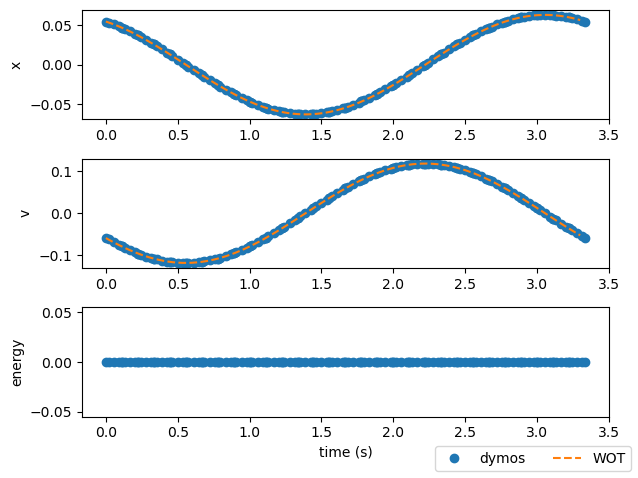

In [8]:
# load in wot results for comparison
wot_results = xr.open_dataset('wot_results.nc')
wot_results = wot_results.sel(realization=0)

states = ['x', 'v','energy']
wot_states = ['pos','vel','energy']
fig, axes = plt.subplots(len(states), 1)
for i, (wot_state, state) in enumerate(zip(wot_states,states)):
    sol = axes[i].plot(t_sol, prob.get_val(f'traj.phase0.timeseries.{state}'), 'o')
    if wot_state != 'energy':
        wot_plots = axes[i].plot(wot_results['time'], np.squeeze(wot_results[wot_state]), '--')
    axes[i].set_ylabel(state)
axes[-1].set_xlabel('time (s)')
fig.legend((sol[0], wot_plots[0]), ('dymos', 'WOT'), loc='lower right', ncol=2)
plt.tight_layout()
plt.show()


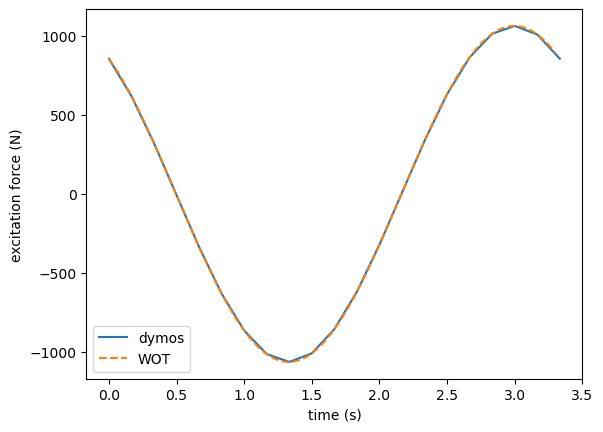

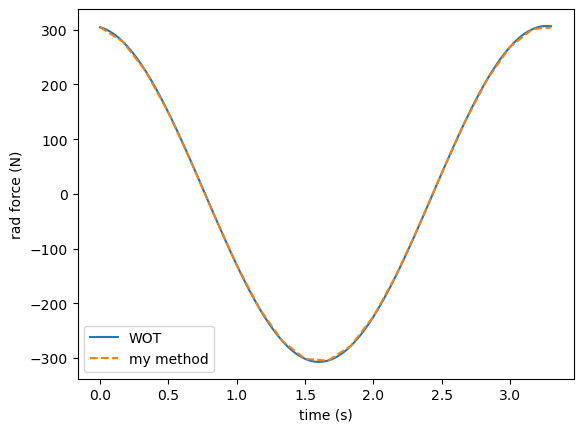

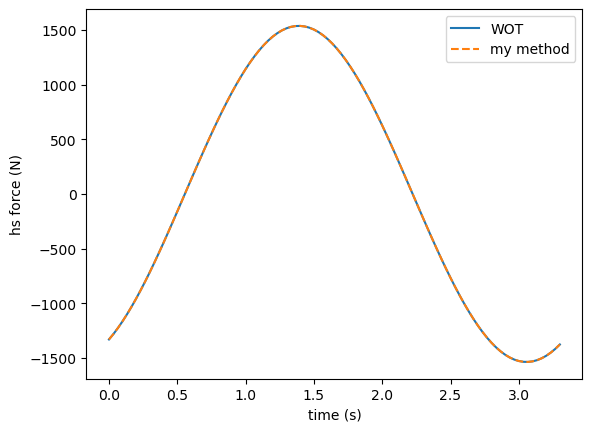

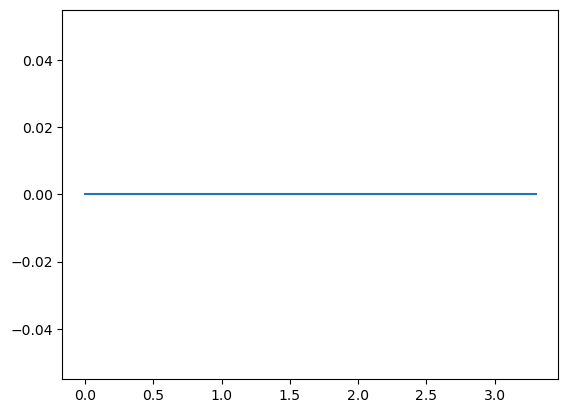

In [9]:
excitation_force_ts = excitation_force_sincos_from_waves_vec(bem_data['excitation_force'], waves.sel(realization=0),  t=t_interp_full)

plt.figure()
plt.plot(t_interp_full, excitation_force_ts,label='dymos')
plt.plot(wot_results['time'],np.squeeze(wot_results['force'].sel(type='diffraction')+wot_results['force'].sel(type='Froude_Krylov')),label='WOT',ls='--')
plt.xlabel('time (s)')
plt.ylabel('excitation force (N)')
plt.legend()

# check if radiation force is being applied correctly by applying it to the wot results and verifying
t = wot_results['time']

omega=bem_data['omega']
radiation_damping=bem_data['radiation_damping']
added_mass=bem_data['added_mass']

t_round = np.round(t, 14)
v_interp = np.interp(t_interp,t_round,np.squeeze(wot_results['vel']))
v_fd = wot.td_to_fd(v_interp)
v_fd_real = wot.complex_to_real(v_fd)

rao_transfer_func_rad = -radiation_damping - 1j*omega*added_mass
transfer_mat = wot.mimo_transfer_mat(rao_transfer_func_rad, False)
time_matrix = wot.time_mat(f1, nfreq)

rad_fd = np.dot(transfer_mat,v_fd_real) #
radiation_damping_force_td = np.dot(time_matrix,rad_fd)
radiation_damping_force_td = np.append(radiation_damping_force_td, radiation_damping_force_td[0])
radiation_damping_force_td_interp = np.interp(t,t_interp_full,np.squeeze(radiation_damping_force_td))

plt.figure()
plt.plot(wot_results['time'],np.squeeze(wot_results['force'].sel(type='radiation')),label='WOT')
plt.plot(t, radiation_damping_force_td_interp, label='my method',ls='--')
plt.xlabel('time (s)')
plt.ylabel('rad force (N)')
plt.legend()

# check hydrostatic force
hydrostatic_stiffness = float(np.squeeze(bem_data['hydrostatic_stiffness'].values))

hs_force = -hydrostatic_stiffness*wot_results['pos']

plt.figure()
plt.plot(wot_results['time'],np.squeeze(wot_results['force'].sel(type='hydrostatics')),label='WOT')
plt.plot(t, np.squeeze(hs_force), label='my method',ls='--')
plt.xlabel('time (s)')
plt.ylabel('hs force (N)')
plt.legend()

plt.figure()
plt.plot(wot_results['time'],np.squeeze(wot_results['force'].sel(type='friction')),label='WOT')